In [1]:
!wget -O pose_landmarker.task -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task

In [3]:
#@markdown To better demonstrate the Pose Landmarker API, we have created a set of visualization tools that will be used in this colab. These will draw the landmarks on a detect person, as well as the expected connections between those markers.

from mediapipe import solutions
from mediapipe.framework.formats import landmark_pb2
import numpy as np


def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  # Loop through the detected poses to visualize.
  for idx in range(len(pose_landmarks_list)):
    pose_landmarks = pose_landmarks_list[idx]

    # Draw the pose landmarks.
    pose_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
    pose_landmarks_proto.landmark.extend([
      landmark_pb2.NormalizedLandmark(x=landmark.x, y=landmark.y, z=landmark.z) for landmark in pose_landmarks
    ])
    solutions.drawing_utils.draw_landmarks(
      annotated_image,
      pose_landmarks_proto,
      solutions.pose.POSE_CONNECTIONS,
      solutions.drawing_styles.get_default_pose_landmarks_style())
  return annotated_image

2026-01-27 12:16:20.077180: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-27 12:16:20.085001: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769516180.093314    1236 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769516180.095786    1236 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-27 12:16:20.104410: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

ImportError: cannot import name 'solutions' from 'mediapipe' (/opt/conda/lib/python3.12/site-packages/mediapipe/__init__.py)

In [6]:
!pip uninstall mediapipe -y

In [2]:
!pip install mediapipe

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 46.1 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 MB 48.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.2.10
    Uninstalling flatbuffers-25.2.10:
      Successfully uninstalled flatbuffers-25.2.10
  Attempting uninstall: absl-py
    Found existing installation: absl-py 2.1.0
    Uninstalling absl-py-2.1.0:
      Successfully uninstalled absl-py-2.1.0


In [20]:
import mediapipe as mp
model_path = './pose_landmarker.task'

# Load the input image from an image file.
mp_image = mp.Image.create_from_file('image.jpg')

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.IMAGE,
output_segmentation_masks=True,)

with PoseLandmarker.create_from_options(options) as landmarker:
    detection_result = landmarker.detect(mp_image)

W0000 00:00:1769532110.564775   43849 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769532110.594944   43849 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [15]:
detection_result

PoseLandmarkerResult(pose_landmarks=[[NormalizedLandmark(x=0.33806538581848145, y=0.1863548755645752, z=-0.1341806799173355, visibility=1.0, presence=1.0, name=None), NormalizedLandmark(x=0.3448467254638672, y=0.15513381361961365, z=-0.11546725034713745, visibility=0.9999997615814209, presence=0.9999998807907104, name=None), NormalizedLandmark(x=0.3519415557384491, y=0.1519753336906433, z=-0.11572464555501938, visibility=0.9999997615814209, presence=0.9999998807907104, name=None), NormalizedLandmark(x=0.35931211709976196, y=0.14900776743888855, z=-0.1156124696135521, visibility=0.9999997615814209, presence=0.9999998807907104, name=None), NormalizedLandmark(x=0.3316265046596527, y=0.16122564673423767, z=-0.10083632916212082, visibility=0.9999998807907104, presence=0.9999998807907104, name=None), NormalizedLandmark(x=0.329121470451355, y=0.16214510798454285, z=-0.10121668875217438, visibility=0.9999998807907104, presence=0.9999998807907104, name=None), NormalizedLandmark(x=0.326817572116

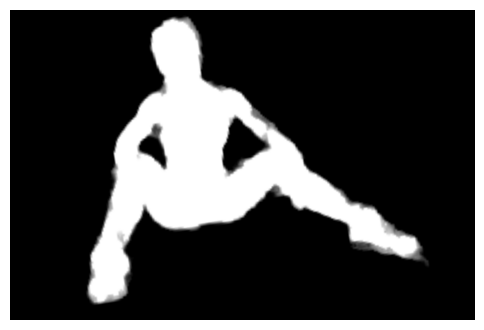

In [24]:
import matplotlib.pyplot as plt
import numpy as np

if detection_result.segmentation_masks:
    mask = detection_result.segmentation_masks[0].numpy_view()  # HxW float [0..1]
    plt.figure(figsize=(6,6))
    plt.imshow(mask, cmap="gray")
    plt.axis("off")
    plt.show()
else:
    print("segmentation_masks is None -> either masks disabled or no pose detected.")

In [27]:
import numpy as np
import cv2
POSE_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,7),
    (0,4),(4,5),(5,6),(6,8),
    (9,10),
    (11,12),
    (11,13),(13,15),(15,17),(15,19),(15,21),(17,19),
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),
    (11,23),(12,24),
    (23,24),
    (23,25),(25,27),(27,29),(29,31),
    (24,26),(26,28),(28,30),(30,32),
    (27,28),
]


def draw_landmarks_on_image(rgb_image, detection_result):
    h, w, _ = rgb_image.shape
    image = rgb_image.copy()

    for pose_landmarks in detection_result.pose_landmarks:
        # Draw points
        for lm in pose_landmarks:
            x = int(lm.x * w)
            y = int(lm.y * h)
            cv2.circle(image, (x, y), 4, (0, 255, 0), -1)

        # Draw connections
        for i, j in POSE_CONNECTIONS:
            p1 = pose_landmarks[i]
            p2 = pose_landmarks[j]
            x1, y1 = int(p1.x * w), int(p1.y * h)
            x2, y2 = int(p2.x * w), int(p2.y * h)
            cv2.line(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

    return image

In [65]:
import mediapipe as mp
import numpy as np
import cv2

mp_pose = mp.tasks.vision.PoseLandmarksConnections
mp_drawing = mp.tasks.vision.drawing_utils
mp_drawing_styles = mp.tasks.vision.drawing_styles

def draw_pose_landmarks_on_image(rgb_image, detection_result):
    pose_landmarks_list = detection_result.pose_landmarks
    annotated_image = np.copy(rgb_image)

    for pose_landmarks in pose_landmarks_list:
        mp_drawing.draw_landmarks(
            annotated_image,
            pose_landmarks,
            mp_pose.POSE_LANDMARKS_CONNECTIONS,   # ✅ correct constant
            mp_drawing_styles.get_default_pose_landmarks_style(),
        )

    return annotated_image


In [66]:
import matplotlib.pyplot as plt

annotated = draw_pose_landmarks_on_image(mp_image.numpy_view(), detection_result)
plt.imshow(annotated)
plt.axis("off")
plt.show()


NameError: name 'POSE_LANDMARKS_CONNECTIONS' is not defined

In [58]:

def get_pose_connections():
    C = mp.tasks.vision.PoseLandmarksConnections
    for name in ["POSE_CONNECTIONS", "POSE_LANDMARKS_CONNECTIONS", "POSE_LANDMARKS"]:
        if hasattr(C, name):
            return getattr(C, name)
    raise AttributeError(f"No pose connections found in {C}. Available: {dir(C)}")

POSE_CONNECTIONS = get_pose_connections()
print("Using:", POSE_CONNECTIONS)


Using: [PoseLandmarksConnections.Connection(start=0, end=1), PoseLandmarksConnections.Connection(start=1, end=2), PoseLandmarksConnections.Connection(start=2, end=3), PoseLandmarksConnections.Connection(start=3, end=7), PoseLandmarksConnections.Connection(start=0, end=4), PoseLandmarksConnections.Connection(start=4, end=5), PoseLandmarksConnections.Connection(start=5, end=6), PoseLandmarksConnections.Connection(start=6, end=8), PoseLandmarksConnections.Connection(start=9, end=10), PoseLandmarksConnections.Connection(start=11, end=12), PoseLandmarksConnections.Connection(start=11, end=13), PoseLandmarksConnections.Connection(start=13, end=15), PoseLandmarksConnections.Connection(start=15, end=17), PoseLandmarksConnections.Connection(start=15, end=19), PoseLandmarksConnections.Connection(start=15, end=21), PoseLandmarksConnections.Connection(start=17, end=19), PoseLandmarksConnections.Connection(start=12, end=14), PoseLandmarksConnections.Connection(start=14, end=16), PoseLandmarksConnec